In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
raw_path = "../data/raw/"

In [3]:
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

In [4]:
n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns

In [5]:
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [7]:
df['target'] = df['ID'].apply(lambda x: 1 if x.startswith('MUSK') else 0)

In [9]:
X = df.drop(columns=['ID', 'target', 'attr_1'])
#X = X.select_dtypes(include=[np.number])
y = df['target']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
print("RAW podaci spremni za modele")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

RAW podaci spremni za modele
X_train: (5278, 167)
X_test: (1320, 167)


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [16]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(C=1.2),
    "KNN": KNeighborsClassifier(n_neighbors=4, weights='distance')
}

## Logisticka Regresija sa raw podacima

Logistic Regression - Train Accuracy: 1.0
Logistic Regression - Test Accuracy:  1.0

Classification Report (Test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       203

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320



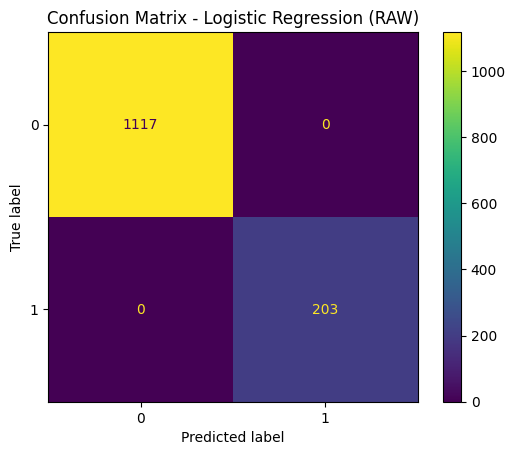

In [20]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression - Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Logistic Regression - Test Accuracy: ", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression (RAW)")
plt.show()

In [21]:
import joblib

joblib.dump(lr_model, "../notebooks/models/lr_raw.pkl")
print("Finalni Logistic Regression model (raw podaci) sačuvan kao lr_raw.pkl")

Finalni Logistic Regression model (raw podaci) sačuvan kao lr_raw.pkl


## SVM sa raw podacima

SVM - Train Accuracy: 1.0
SVM - Test Accuracy:  1.0

Classification Report (Test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       203

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320



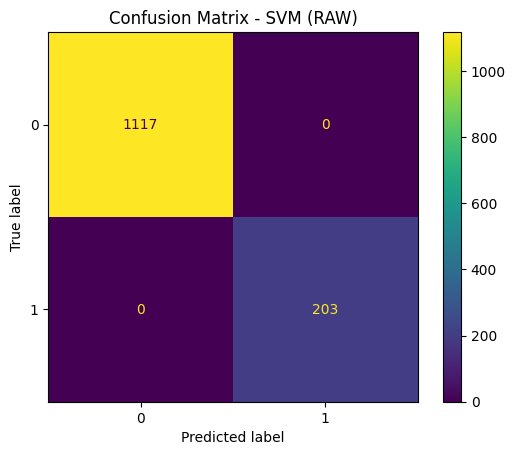

In [22]:
svm_model = SVC(C=1.2)

svm_model.fit(X_train_scaled, y_train)

y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

print("SVM - Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("SVM - Test Accuracy: ", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - SVM (RAW)")
plt.show()

In [23]:
joblib.dump(svm_model, "../notebooks/models/svm_raw.pkl")
print("Finalni SVM model (raw podaci) sačuvan kao svm_raw.pkl")

Finalni SVM model (raw podaci) sačuvan kao svm_raw.pkl


## KNN sa raw podacima

KNN - Train Accuracy: 1.0
KNN - Test Accuracy:  0.9772727272727273

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1117
           1       0.96      0.89      0.92       203

    accuracy                           0.98      1320
   macro avg       0.97      0.94      0.95      1320
weighted avg       0.98      0.98      0.98      1320



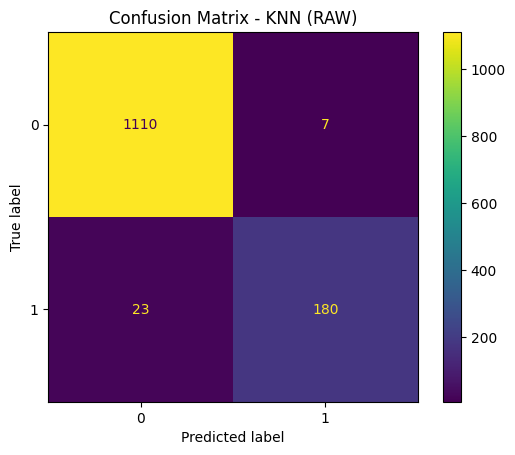

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=4, weights='distance')

knn_model.fit(X_train_scaled, y_train)

y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

print("KNN - Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("KNN - Test Accuracy: ", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - KNN (RAW)")
plt.show()

In [26]:
joblib.dump(knn_model, "../notebooks/models/knn_raw.pkl")
print("Finalni KNN model (raw podaci) sačuvan kao knn_raw.pkl")

Finalni KNN model (raw podaci) sačuvan kao knn_raw.pkl


## Decision Tree sa raw podacima

Decision Tree - Train Accuracy: 1.0
Decision Tree - Test Accuracy:  1.0

Classification Report (Test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       203

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320



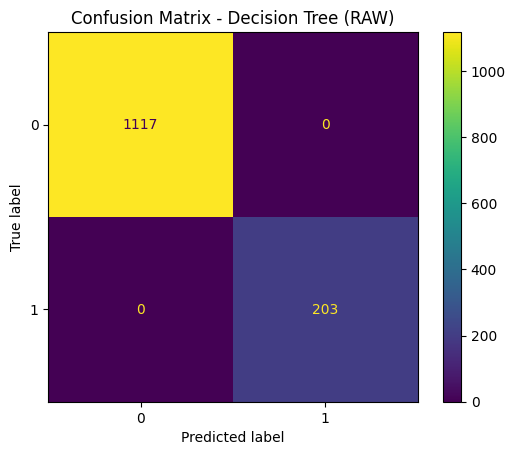

In [27]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train_scaled, y_train)

y_train_pred = dt_model.predict(X_train_scaled)
y_test_pred = dt_model.predict(X_test_scaled)

print("Decision Tree - Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Decision Tree - Test Accuracy: ", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree (RAW)")
plt.show()

In [28]:
joblib.dump(dt_model, "../notebooks/models/dt_raw.pkl")
print("Finalni Decision Tree model (raw podaci) sačuvan kao dt_raw.pkl")

Finalni Decision Tree model (raw podaci) sačuvan kao dt_raw.pkl


## Random Forest sa raw podacima

Random Forest - Train Accuracy: 1.0
Random Forest - Test Accuracy:  1.0

Classification Report (Test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       203

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320



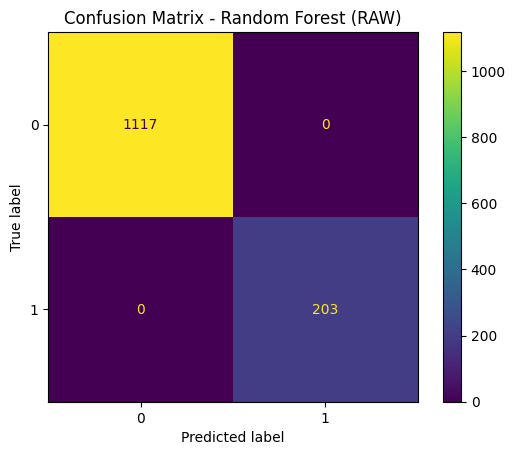

In [29]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

print("Random Forest - Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Random Forest - Test Accuracy: ", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest (RAW)")
plt.show()

In [30]:
joblib.dump(rf_model, "../notebooks/models/rf_raw.pkl")
print("Finalni Random Forest model (raw podaci) sačuvan kao rf_raw.pkl")

Finalni Random Forest model (raw podaci) sačuvan kao rf_raw.pkl
